# 19 May 2026 - making figures for CV paper

In [1]:

import json
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


plt.rcParams.update(plt.rcParamsDefault)
with open('/data/taylor_group/levi_schult/ng15_rcparams.json', 'rb') as fin:
    plt.rcParams.update(json.load(fin))
plt.style.use('seaborn-v0_8-colorblind')


%matplotlib inline
%config InlineBackend.figure_format='retina'

## import pkls

In [2]:
# LSS all 4 year for now
cvkpc = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/kpcsn/rseed2035_zh280pc/dur12p6e7_inj_CVkpcpop1-rs2035zh280_GBpop2_rec_n_doublebrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
cvthin = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thin/dur12p6e7_inj_CVgxypop1-rs2035thin_GBpop2_rec_n_doublebrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
cvthick = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thick/dur12p6e7_inj_CVgxypop1-rs2035thick_GBpop2_rec_n_doublebrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
cvthin_stepthin = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thin/dur12p6e7_inj_CVgxypop1-rs2035thin_GBpop2_rec_n_doublebrokentruncPLpfixedgal_onestep2parfixedgalthin/plot_data.pickle', 'rb'))
cvthick_stepthick = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thick/dur12p6e7_inj_CVgxypop1-rs2035thick_GBpop2_rec_n_onestep2parfixedgalthick_dblbrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
dwdthin_dbtpl = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/DBTPL_GBpop_control/dur12p6e7_inj_GBpop2_rec_n_dblbroketruncpowlawfixedgal/plot_data.pickle', 'rb'))

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/schultls/.local/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/schultls/.local/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/schultls/.local/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


## freq dist of CVs (kpc and full gxy)

In [3]:
cvkpc_blip = pd.read_csv('/home/schultls/levi_schult/blip_CVs/datasets/kpcsn/dat_kpcsn_emgap_combined_zh280pc_rs2035_nsamp1.0e+06_BLIP_final.txt', delimiter=' ', header=None)
cvkpc_blip.columns = ['f', 'h', 'lat', 'long']
cvthin_blip = pd.read_csv('/home/schultls/levi_schult/blip_CVs/datasets/MW_CVs/rseed2035_thin/dat_fullgxy_emgap_combined_thin_rs2035_nsamp1.0e+06_BLIP_final.txt', delimiter=' ', header=None)
cvthin_blip.columns = ['f', 'h', 'lat', 'long']
cvthick_blip = pd.read_csv('/home/schultls/levi_schult/blip_CVs/datasets/MW_CVs/rseed2035_thick/dat_fullgxy_emgap_combined_thick_rs2035_nsamp1.0e+06_BLIP_final.txt', delimiter=' ', header=None)
cvthick_blip.columns = ['f', 'h', 'lat', 'long']


(0.00015, 0.00036)

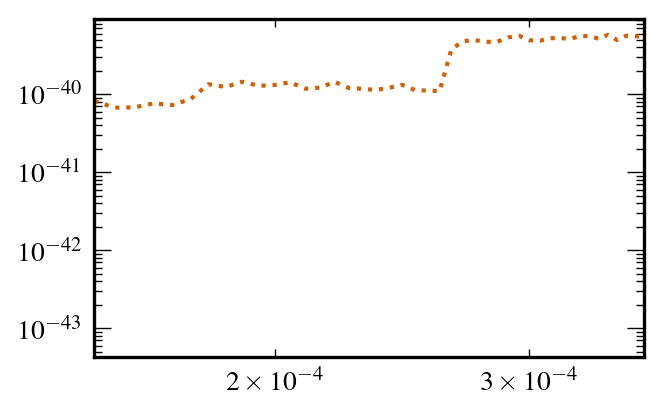

In [31]:
plt.plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thick', color='C2', linestyle='dotted')
plt.loglog()
plt.xlim(.15e-3, .36e-3)


(1e-41, 1e-38)

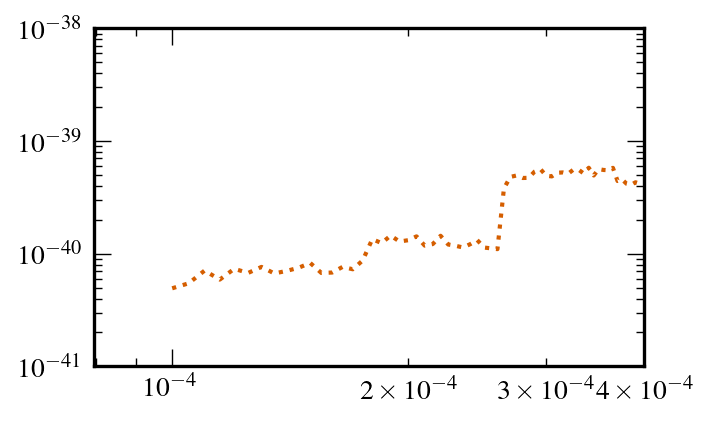

In [36]:
plt.plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thick', color='C2', linestyle='dotted')
plt.loglog()
plt.xlim(right=.4e-3)
plt.ylim(bottom=1e-41, top=1e-38)


## CV kpc & CV gxy vs control

/tmp/ipykernel_603936/3040853538.py:39: RuntimeWarning: divide by zero encountered in divide
  return (2 / (P_orb*60)) # LSS convert porb in minutes to fgw in mHz


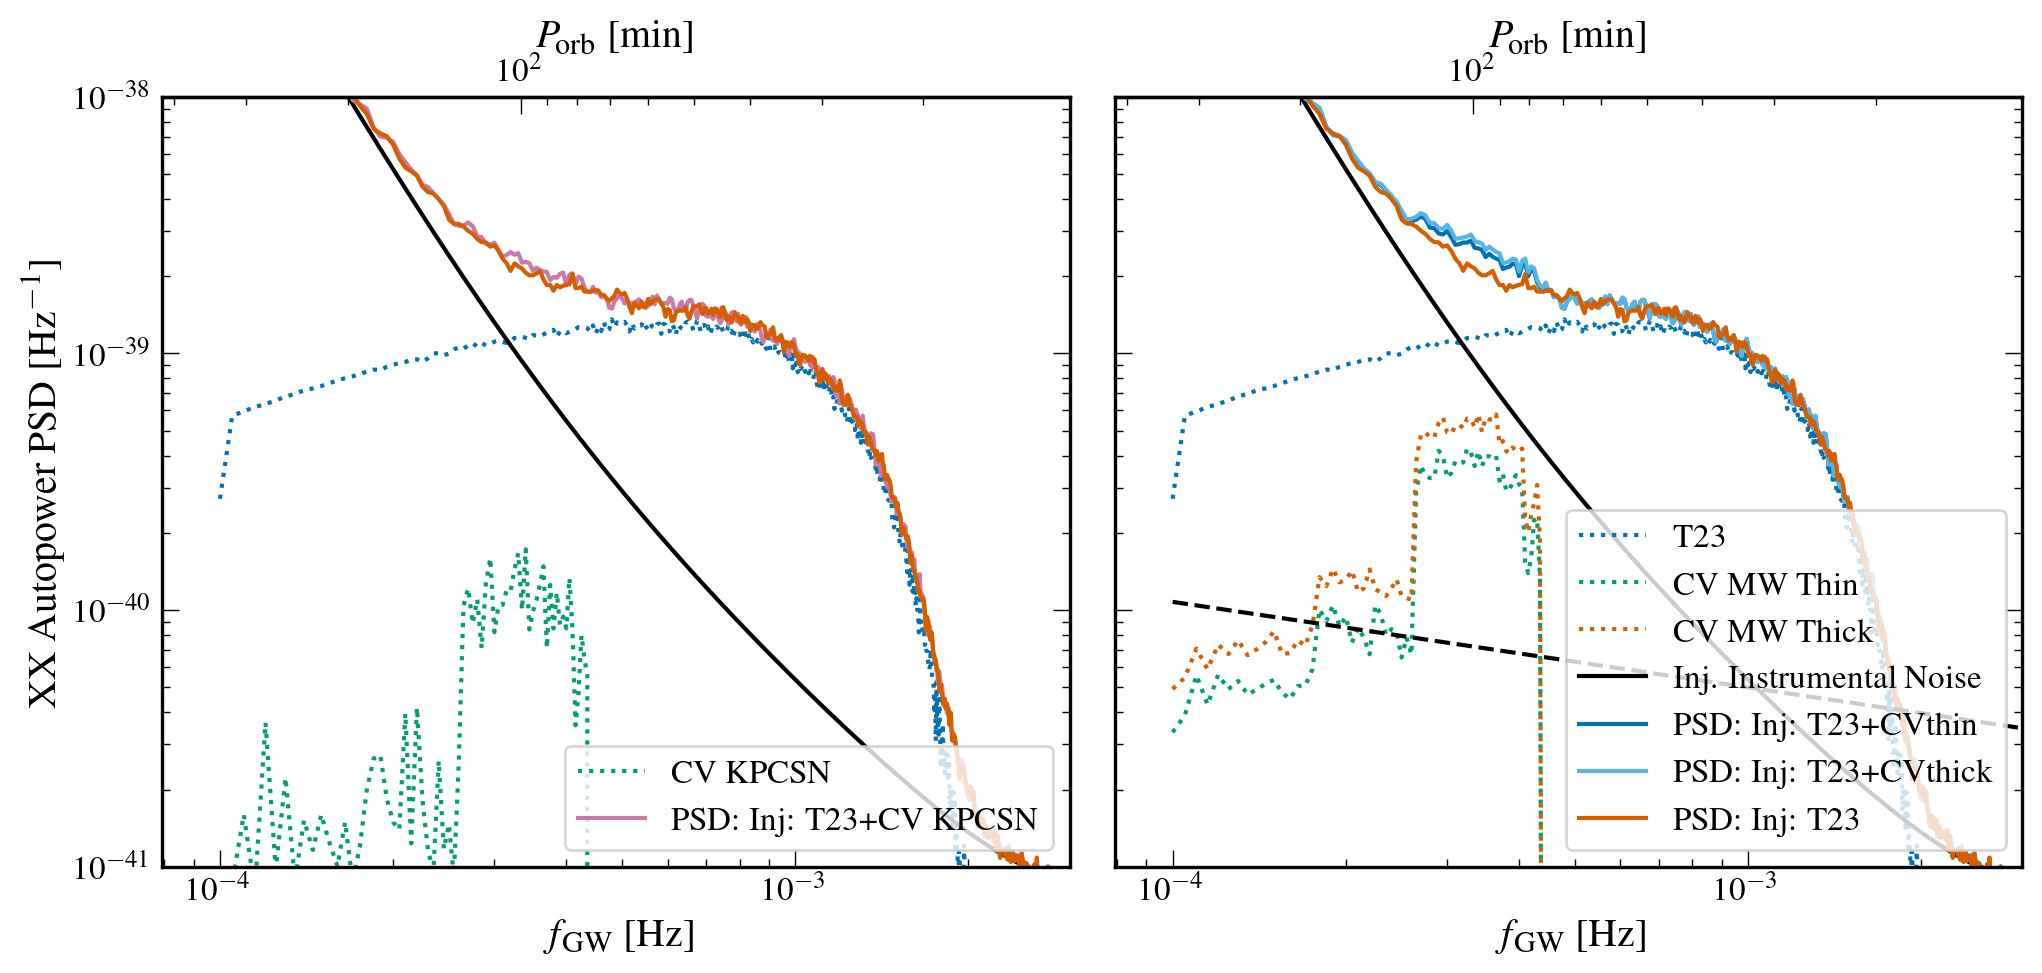

In [ ]:
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True,figsize=(12, 5))


####### KPCSN COMPARISON ########
# populations.
ax[0].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], color='C0', linestyle='dotted')
ax[0].plot(cvkpc['fit_data']['fs'], cvkpc['fit_data']['det_inj']['population-1']['spec'], label='CV KPCSN', color='C1', linestyle='dotted')

# noise
ax[0].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['noise']['spec'], color='k')

# kpcsn PSD comparison
ax[0].plot(cvkpc['injspec_data']['data_psd']['psdfreqs'], cvkpc['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23+CV KPCSN', color='C3')
ax[0].plot(dwdthin_dbtpl['injspec_data']['data_psd']['psdfreqs'], dwdthin_dbtpl['injspec_data']['data_psd']['psd1'], color='C2')

####### FULL GXY COMPARISON ########
# populations.
ax[1].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0', linestyle='dotted')
ax[1].plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thin', color='C1', linestyle='dotted')
ax[1].plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thick', color='C2', linestyle='dotted')

# noise
ax[1].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['noise']['spec'], label='Inj. Instrumental Noise', color='k')

# MW PSD comparison
ax[1].plot(cvthin['injspec_data']['data_psd']['psdfreqs'], cvthin['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23+CVthin', color='C6')
ax[1].plot(cvthick['injspec_data']['data_psd']['psdfreqs'], cvthick['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23+CVthick', color='C5')
ax[1].plot(dwdthin_dbtpl['injspec_data']['data_psd']['psdfreqs'], dwdthin_dbtpl['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23', color='C2')

#ax[1].plot(cvthin['injspec_data']['data_psd']['psdfreqs'], .5e-41*cvthin['injspec_data']['data_psd']['psdfreqs']**(-1/3), linestyle='dashed', color='k')

ax[0].tick_params(top=False, which='both', labelsize='large')
ax[1].tick_params(top=False, which='both', labelsize='large')

def gw_Hz_to_P_orb(gw_mHz): # LSS convert fgw to porb in minutes
    return (2 / (gw_mHz))/60

def P_orb_to_gw_Hz(P_orb):
    return (2 / (P_orb*60)) # LSS convert porb in minutes to fgw in mHz

secax0 = ax[0].secondary_xaxis('top', functions=(gw_Hz_to_P_orb, P_orb_to_gw_Hz))
secax0.set_xlabel(r'$P_{\rm orb}$ [min]', fontsize='x-large')
secax0.set_xticks([100, 200, 300])
secax0.tick_params(labelsize='large')
secax1 = ax[1].secondary_xaxis('top', functions=(gw_Hz_to_P_orb, P_orb_to_gw_Hz))
secax1.set_xlabel(r'$P_{\rm orb}$ [min]', fontsize='x-large')
secax1.set_xticks([100, 200, 300])
secax1.tick_params(labelsize='large')

ax[0].loglog()
ax[0].set_xlim(right=3e-3)
ax[0].legend(loc='lower right', fontsize='large')
ax[1].legend(loc='lower right', fontsize='large')
ax[0].set_ylim(bottom=1e-41, top=1e-38)
ax[0].set_xlabel(r'$f_{\rm GW}$ [Hz]', fontsize='x-large')
ax[1].set_xlabel(r'$f_{\rm GW}$ [Hz]', fontsize='x-large')
ax[0].set_ylabel(r'XX Autopower PSD [$\rm{Hz }^{-1}$]', fontsize='x-large')
plt.subplots_adjust(wspace=0.05)
plt.savefig('/home/schultls/levi_schult/blip_CVs/notebooks/figures/paperfigs/fig2_PSD_comparison.pdf', bbox_inches='tight', dpi=400, format='pdf')

(1e-41, 1e-38)

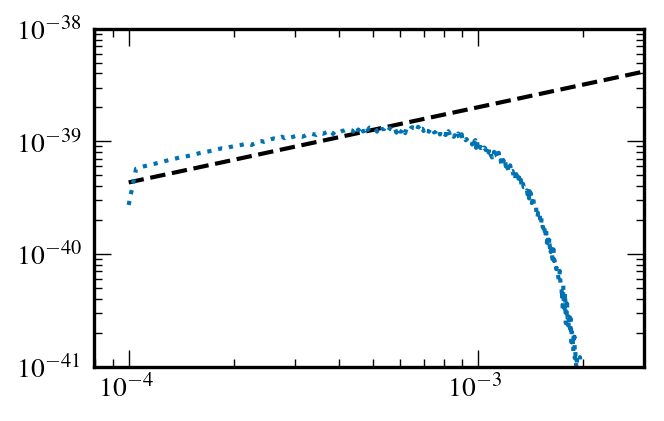

In [58]:
plt.plot(cvthin['injspec_data']['data_psd']['psdfreqs'], .2e-38*(cvthin['injspec_data']['data_psd']['psdfreqs']/1e-3)**(2/3), linestyle='dashed', color='k')
plt.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0', linestyle='dotted')
plt.loglog()
plt.xlim(right=3e-3)
plt.ylim(bottom=1e-41, top=1e-38)

## Spectral recovery of DWDthin (impact of CVs)

/tmp/ipykernel_603936/1603498854.py:47: RuntimeWarning: divide by zero encountered in divide
  return (2 / (P_orb*60)) # LSS convert porb in minutes to fgw in mHz


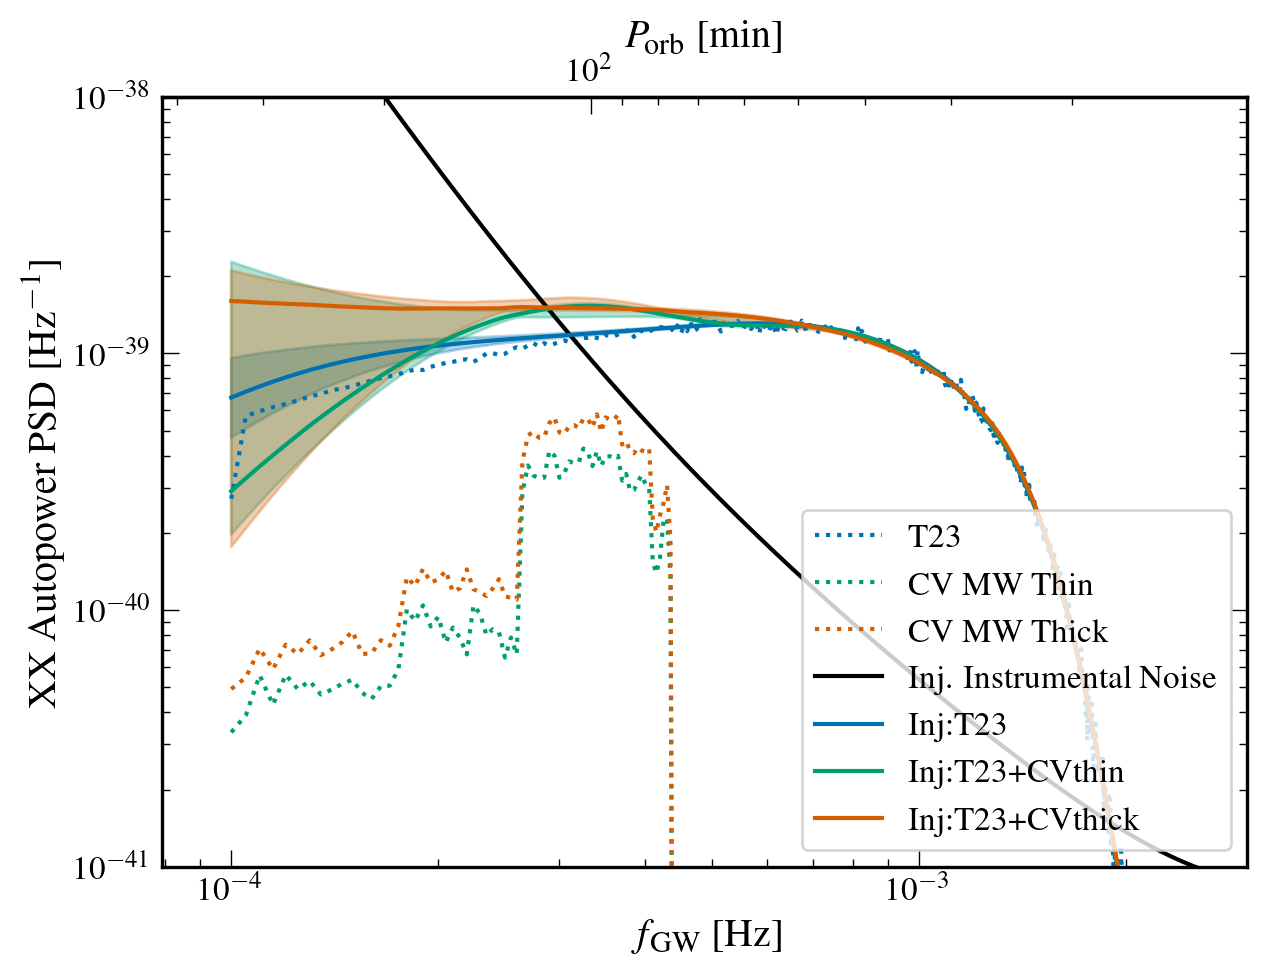

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

# populations.
ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0', linestyle='dotted')
ax.plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thin', color='C1', linestyle='dotted')
ax.plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thick', color='C2', linestyle='dotted')


# noise
ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['noise']['spec'], label='Inj. Instrumental Noise', color='k')

# noise recovery
# ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_fits']['noise']['median'], 
#         label='Inj:T23 - Recovered Instrumental Noise', color='k', alpha=0.5)
# ax.plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_fits']['noise']['median'], 
#         label='Inj:T23+CVthin - Recovered Instrumental Noise', color='k', linestyle='dashed')


# No CVs injected
ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
         label='Inj:T23', color='C0')
ax.fill_between(dwdthin_dbtpl['fit_data']['fs'], 
                dwdthin_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                dwdthin_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C0')

# CVs thin injected
ax.plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
         label='Inj:T23+CVthin', color='C1')
ax.fill_between(cvthin['fit_data']['fs'], 
                cvthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                cvthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C1')

# CVs thick injected
ax.plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
         label='Inj:T23+CVthick', color='C2')
ax.fill_between(cvthick['fit_data']['fs'], 
                cvthick['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                cvthick['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C2')


ax.tick_params(top=False, which='both', labelsize='large')

def gw_Hz_to_P_orb(gw_mHz): # LSS convert fgw to porb in minutes
    return (2 / (gw_mHz))/60

def P_orb_to_gw_Hz(P_orb):
    return (2 / (P_orb*60)) # LSS convert porb in minutes to fgw in mHz

secax0 = ax.secondary_xaxis('top', functions=(gw_Hz_to_P_orb, P_orb_to_gw_Hz))
secax0.set_xlabel(r'$P_{\rm orb}$ [min]', fontsize='x-large')
secax0.set_xticks([100, 200, 300])
secax0.tick_params(labelsize='large')

ax.loglog()
ax.set_xlim(right=3e-3)
ax.legend(loc='lower right', fontsize='large')
ax.set_ylim(bottom=1e-41, top=1e-38)
ax.set_xlabel(r'$f_{\rm GW}$ [Hz]', fontsize='x-large')
ax.set_ylabel(r'XX Autopower PSD [$\rm{Hz }^{-1}$]', fontsize='x-large')
plt.savefig('/home/schultls/levi_schult/blip_CVs/notebooks/figures/paperfigs/fig3_DWD_bias_comparison.pdf', bbox_inches='tight', dpi=400, format='pdf')

## Attempts at Spectral Separation

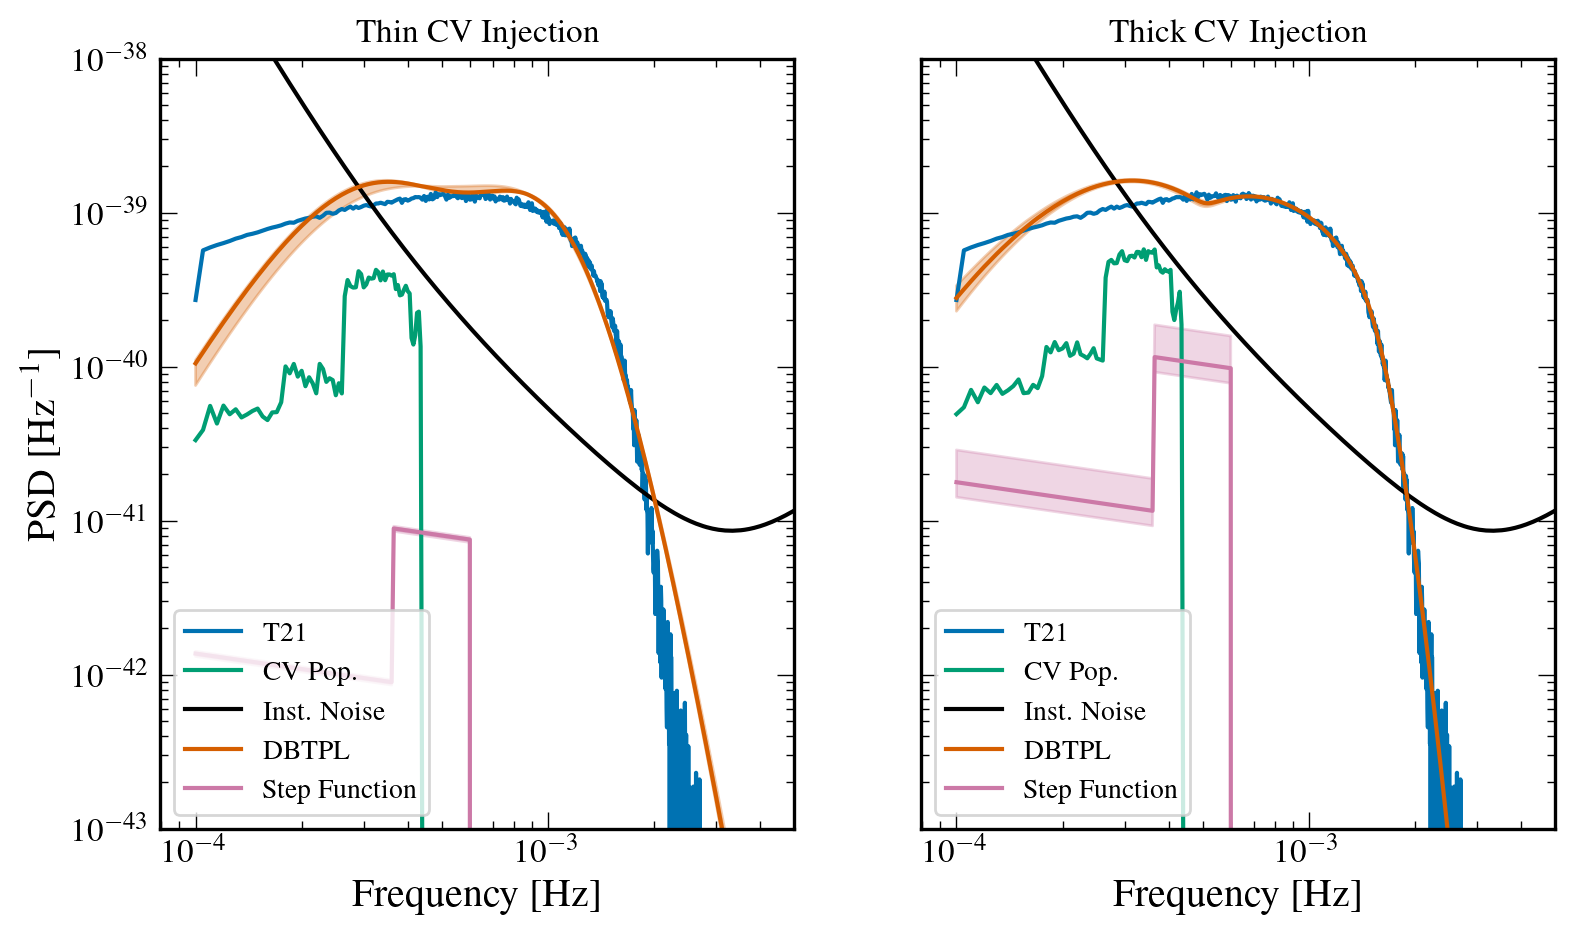

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

runs = [cvthin_stepthin, cvthick_stepthick]
radht = ['Thin', 'Thick']

for idx, run in enumerate(runs):

    # populations.
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0', linestyle='dotted')
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_inj']['population-1']['spec'], label=f'CV MW {radht[idx]}', color='C1', linestyle='dotted')

    # noise
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_inj']['noise']['spec'], label='Inst. Noise', color='k')

    # DWD DBTPL recovery
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
            label=f'DBTPL', color='C2')
    ax[idx].fill_between(run['fit_data']['fs'], 
                    run['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                    run['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C2')

    # CVs thin recovered
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['median'],
            label=f'Step Function', color='C3')
    ax[idx].fill_between(run['fit_data']['fs'], 
                    run['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['lower95'], 
                    run['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['upper95'], alpha=0.3, color='C3')

    # CVs thick injected

    ax[idx].set_title(f'{radht[idx]} CV Injection', fontsize='large')
    ax[idx].loglog()
    ax[idx].legend(loc='lower left', fontsize='medium')
    ax[idx].set_xlim(right=5e-3)
    ax[idx].set_ylim(bottom=1e-43, top=1e-38)
    ax[idx].set_xlabel('Frequency [Hz]', fontsize='x-large')
    ax[idx].tick_params(axis='both', which='major', labelsize='large')


ax[0].set_ylabel(r'PSD [$\rm{Hz }^{-1}$]', fontsize='x-large')

plt.show()

In [ ]:
ax.plot(cvthin_stepthin['fit_data']['fs'], cvthin_stepthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'], label='CVthin:stepthin+fixgalthin', color='C2')
ax.fill_between(cvthin_stepthin['fit_data']['fs'], 
                cvthin_stepthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                cvthin_stepthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C2')


In [ ]:
fig, ax = plt.subplots()

ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['data_psd']['psd1']), label='ASD with CVs')
ax.plot(noCV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(noCV_plot['injspec_data']['data_psd']['psd1']), label='ASD without CVs')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['noise_spectra']['noise1']), label='Instrumental Noise')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['truncatedpowerlaw4par_fixedgalaxy']['S1_gw']), label='Injected GB Spectrum')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['population']['S1_gw']), label='CV Population')

ax.loglog()
ax.set_xlim(right=3e-3)
ax.set_ylim(bottom=1e-21, top=3e-19)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [$\rm{Hz}^{-1/2}$]')

## fixed DBTPL and CV recovery

In [19]:
fixDBTPLCV = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/fixDBTPLtsts/dur3p2e7_inj_CVgxypop1-rs2035thin_DBTPLfixgal_rec_n_allfixedDBTPLfixedgal_onestep2parfixedgalthin/plot_data.pickle', 'rb'))

In [27]:
fixDBTPLCV['fit_data']['det_fits']

{'noise': {'median': array([3.78950237e-37, 3.13687102e-37, 2.62100326e-37, ...,
         3.83071738e-41, 3.83374900e-41, 3.83678184e-41], shape=(1981,)),
  'upper95': array([3.80887232e-37, 3.15290359e-37, 2.63439794e-37, ...,
         3.83926715e-41, 3.84230601e-41, 3.84534611e-41], shape=(1981,)),
  'lower95': array([3.77069505e-37, 3.12130586e-37, 2.60800055e-37, ...,
         3.82138273e-41, 3.82440576e-41, 3.82743002e-41], shape=(1981,))},
 'ALLFIXEDT23doublebrokentruncpowerlaw_fixedgalaxy': {'median': array([5.05747767e-41, 5.38360075e-41, 5.70600191e-41, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(1981,)),
  'upper95': array([5.05747767e-41, 5.38360075e-41, 5.70600191e-41, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(1981,)),
  'lower95': array([5.05747767e-41, 5.38360075e-41, 5.70600191e-41, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(1981,))},
 'onesidestep2par_fixedgalaxy': {'median': array([1.38698

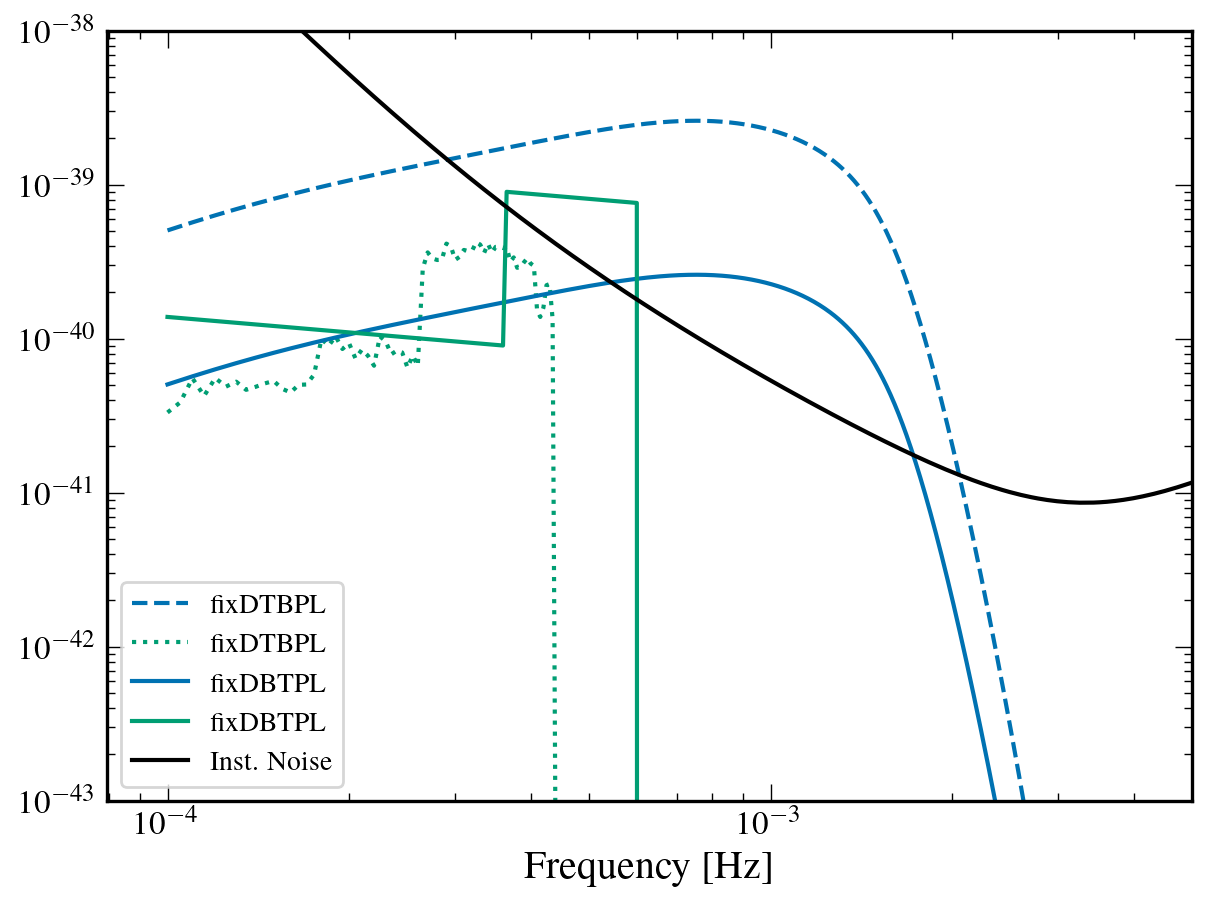

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

# injected spectra
ax.plot(fixDBTPLCV['fit_data']['fs'], fixDBTPLCV['fit_data']['det_inj']['doublebrokentruncpowerlaw_fixedgalaxy']['spec'], label='fixDTBPL', color='C0', linestyle='dashed')
ax.plot(fixDBTPLCV['fit_data']['fs'], fixDBTPLCV['fit_data']['det_inj']['population-1']['spec'], label='fixDTBPL', color='C1', linestyle='dotted')

ax.plot(fixDBTPLCV['fit_data']['fs'], fixDBTPLCV['fit_data']['det_fits']['ALLFIXEDT23doublebrokentruncpowerlaw_fixedgalaxy']['median'], label='fixDBTPL', color='C0')
ax.plot(fixDBTPLCV['fit_data']['fs'], fixDBTPLCV['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['median'], label='fixDBTPL', color='C1')

ax.plot(fixDBTPLCV['fit_data']['fs'], fixDBTPLCV['fit_data']['det_inj']['noise']['spec'], label='Inst. Noise', color='k')


ax.loglog()
ax.legend(loc='lower left', fontsize='medium')
ax.set_xlim(right=5e-3)
ax.set_ylim(bottom=1e-43, top=1e-38)
ax.set_xlabel('Frequency [Hz]', fontsize='x-large')
ax.tick_params(axis='both', which='major', labelsize='large')

